In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import sys
sys.path.append('../src/')
from probabilistic_model import ProbabilisticModel

In [14]:
def load_data(model, state):
    '''Method for loading descriptors for the provided model and state.'''
    acsf = np.load(f'../data/descriptors/neigh_16/{model}_{state}_acsf.npy')
    stein = np.load(f'../data/descriptors/neigh_16/{model}_{state}_stein.npy')
    X = np.hstack((acsf, stein))
    return X

In [15]:
def visualize_features(desc, model, hda_desc, lda_desc):
    '''
        Method for visualizing distribution of a state's features
        along the features chosen by the classification model for
        comparison to HDA and LDA distributions.
    '''
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.linewidth'] = 1.1
    fig, axs = plt.subplots(1,5,figsize=(12.0,3.5))
    for feat_idx, feat in enumerate(model.chosen_features):
        candidate = desc[:,feat]
        hda = hda_desc[:,feat]
        lda = lda_desc[:,feat]
        axs[feat_idx].hist(candidate, bins=30, density=True, color='gray', alpha=0.5, label='Trial')
        axs[feat_idx].hist(hda, bins=30, density=True, color='blue', alpha=0.5, label='HDA')
        axs[feat_idx].hist(lda, bins=30, density=True, color='red', alpha=0.5, label='LDA')
        axs[feat_idx].spines[['top', 'right']].set_visible(False)
        axs[feat_idx].set_xlabel(f'Desc #{feat_idx + 1}')
        # axs[feat_idx].set_ylabel('')
        axs[feat_idx].set_yticks([])
    plt.tight_layout()
    plt.show()

In [23]:
MODEL = 'scan'
m1 = pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_5_include_0.999.pkl', 'rb'))
m2 = pickle.load(open(f'../data/models/model_{MODEL}_size_16_feat_120_include_0.999.pkl', 'rb'))

phases = ['ice01c', 'ice02', 'ice03', 'ice04', 'ice05', 'ice06',
          'ice07', 'ice08', 'ice09', 'ice11', 'ice12', 'ice13', 'ice14', 'ice15']

scan_results = {}
for phase in phases:
    desc = load_data(MODEL, phase)
    y1 = m1.predict(desc)
    y2 = m2.predict(desc)
    scan_results[phase] = {'m1': np.mean(y1 == -1), 'm2': np.mean(y2 == -1), 'desc': desc}

print(f'DP_SCAN — outlier detection rate')
print(f'{"Phase":10s} {"m1":>12s} {"m2":>14s}')
print('-' * 45)
for phase in phases:
    r = scan_results[phase]
    print(f'{phase:10s} {r["m1"]:>11.3f} {r["m2"]:>13.3f}')

DP_SCAN — outlier detection rate
Phase                m1             m2
---------------------------------------------
ice01c           0.996         0.998
ice02            0.000         0.000
ice03            0.004         0.970
ice04            0.362         0.114
ice05            0.010         0.980
ice06            0.450         0.772
ice07            1.000         1.000
ice08            1.000         1.000
ice09            0.000         1.000
ice11            1.000         1.000
ice12            0.260         1.000
ice13            0.000         0.932
ice14            0.342         1.000
ice15            0.832         0.978


In [26]:
MODEL = 'mbpol'
m1_mb = pickle.load(open('../data/models/model_mbpol_size_16_feat_5_include_0.999.pkl', 'rb'))
m2_mb = pickle.load(open('../data/models/model_mbpol_size_16_feat_120_include_0.999.pkl', 'rb'))

mbpol_results = {}
for phase in phases:
    desc = load_data(MODEL, phase)
    y1 = m1.predict(desc)
    y2 = m2.predict(desc)
    mbpol_results[phase] = {'m1': np.mean(y1 == -1), 'm2': np.mean(y2 == -1), 'desc': desc}

print(f'DP_MBpol — outlier detection rate')
print(f'{"Phase":10s} {"m1":>12s} {"m2":>14s}')
print('-' * 45)
for phase in phases:
    r = mbpol_results[phase]
    print(f'{phase:10s} {r["m1"]:>11.3f} {r["m2"]:>13.3f}')

DP_MBpol — outlier detection rate
Phase                m1             m2
---------------------------------------------
ice01c           0.994         1.000
ice02            0.037         0.055
ice03            0.000         0.818
ice04            0.072         0.038
ice05            0.002         0.874
ice06            0.142         0.570
ice07            1.000         1.000
ice08            1.000         1.000
ice09            0.000         0.966
ice11            0.950         0.986
ice12            0.070         0.986
ice13            0.000         0.780
ice14            0.072         0.996
ice15            0.334         0.784


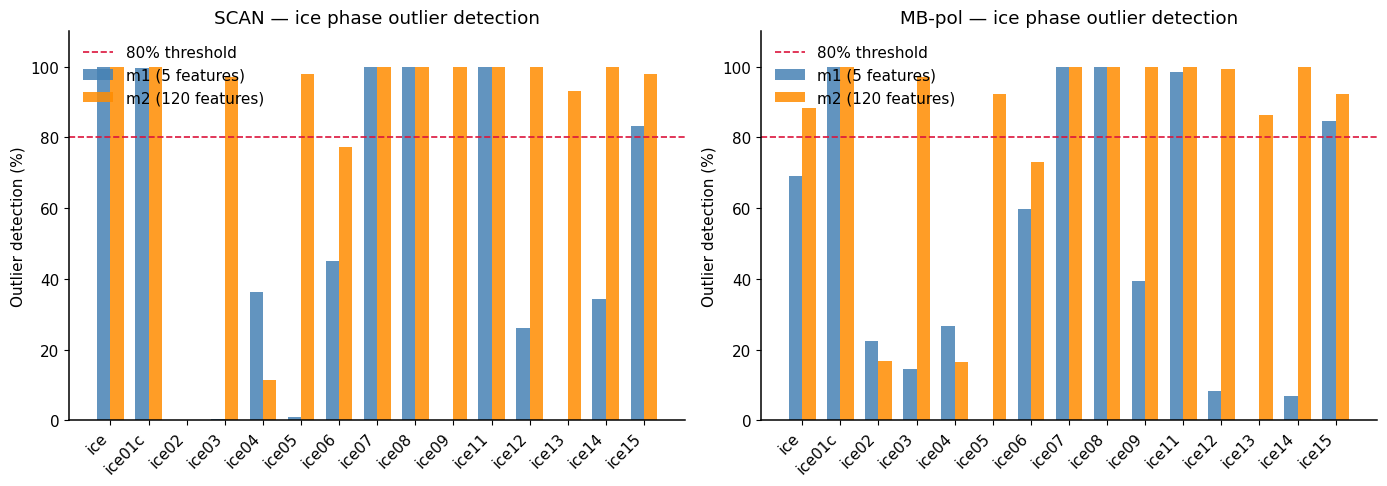

In [19]:
#plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(phases))
w = 0.35

for ax, results, title in [
    (axes[0], scan_results, 'SCAN'),
    (axes[1], mbpol_results, 'MB-pol'),
]:
    m1_vals = [results[p]['m1'] if not np.isnan(results[p]['m1']) else 0 for p in phases]
    m2_vals = [results[p]['m2'] if not np.isnan(results[p]['m2']) else 0 for p in phases]

    ax.bar(x - w/2, m1_vals, w, label='m1 (5 features)', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, m2_vals, w, label='m2 (120 features)', color='darkorange', alpha=0.85)
    ax.axhline(80, color='crimson', linestyle='--', linewidth=1.2, label='80% threshold')
    ax.set_xticks(x)
    ax.set_xticklabels(phases, rotation=45, ha='right')
    ax.set_ylabel('Outlier detection (%)')
    ax.set_title(f'{title} — ice phase outlier detection')
    ax.set_ylim(0, 110)
    ax.legend(frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('../notebooks/outlier_detection_summary.pdf', bbox_inches='tight')
plt.show()

/home/rs4732/.conda/envs/amorphous_ice/lib/python3.9/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


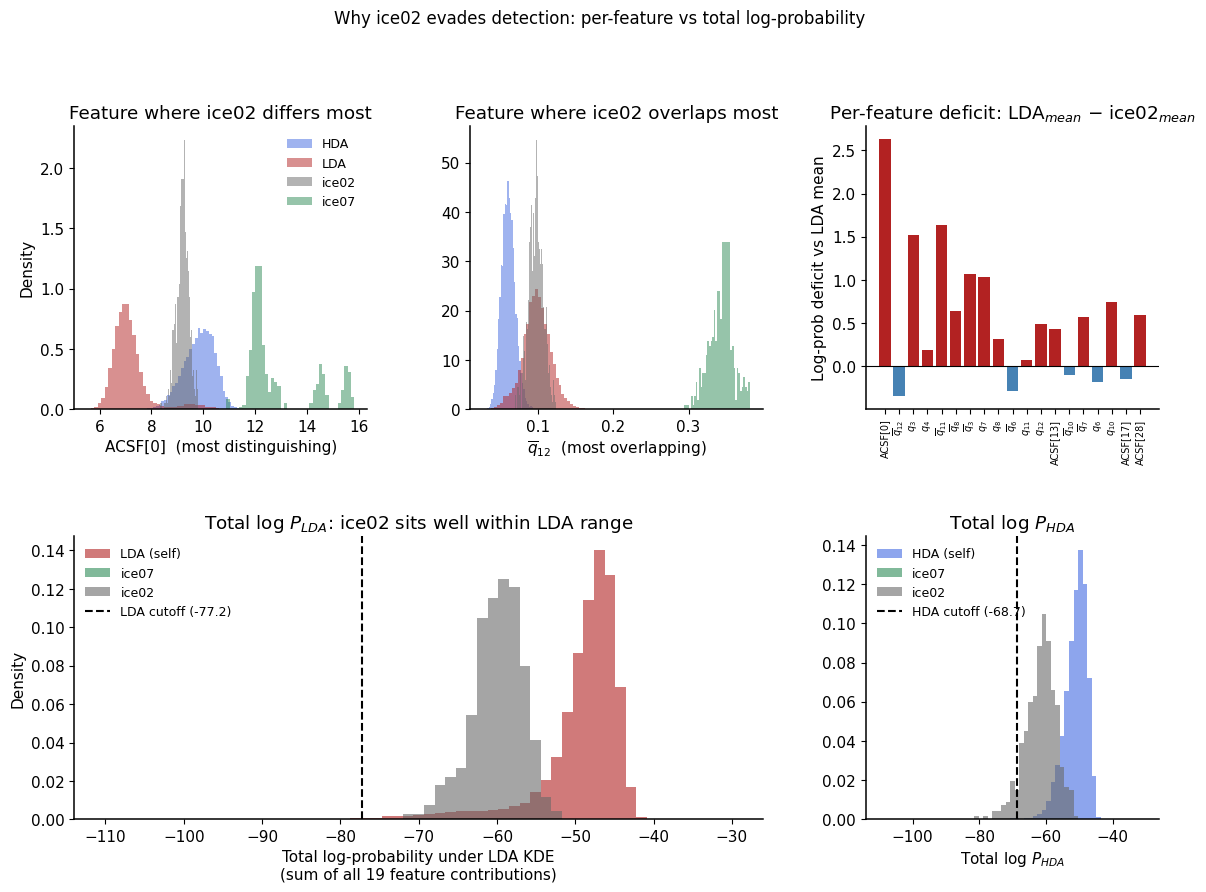

Interpretation:
  Most distinguishing feature: ACSF[0] (deficit=2.63)
  ice02 log P_LDA mean = -60.0  vs  LDA cutoff = -77.2
  ice02 log P_HDA mean = -62.4  vs  HDA cutoff = -68.7
  ice07 log P_LDA mean = -487.0  (clearly below cutoff)


In [20]:
# --- Log-probability analysis for ice02 (zero-detection case) ---
# Shows why 1-2 distinguishing features cannot overcome the full product of log-probs.

import torch

stein_names = ['q3','q4','q5','q6','q7','q8','q9','q10','q11','q12',
               'av_q3','av_q4','av_q5','av_q6','av_q7','av_q8','av_q9',
               'av_q10','av_q11','av_q12',
               'w4','w6','w8','w10','w12','av_w4','av_w6','av_w8','av_w10','av_w12']
def feat_label(i):
    return f'ACSF[{i}]' if i < 90 else f'$\\overline{{q}}_{{{stein_names[i-90].replace("av_q","").replace("q","")}}}$' \
        if 'av_q' in stein_names[i-90] else f'$q_{{{stein_names[i-90].replace("q","")}}}$'

hda_desc  = load_data(MODEL, 'hda')
lda_desc  = load_data(MODEL, 'lda')
ice02_desc = load_data(MODEL, 'ice02')
ice07_desc = load_data(MODEL, 'ice07')

# Per-feature log-prob contributions for ice02 under LDA KDE
def per_feature_logprob(model, X, c):
    X_t = torch.tensor(X, dtype=torch.float)
    out = []
    for i, idx in enumerate(model.keep_idx):
        p = model.eval_funcs[c][i].evaluate(X_t[:, idx])
        out.append(torch.log(p + 1e-30).numpy())
    return np.stack(out, axis=1)  # (n_samples, n_features)

lda_pf_lda   = per_feature_logprob(m2, lda_desc,   1)   # LDA under LDA KDE
ice02_pf_lda = per_feature_logprob(m2, ice02_desc, 1)   # ice02 under LDA KDE
ice07_pf_lda = per_feature_logprob(m2, ice07_desc, 1)   # ice07 under LDA KDE

# Identify: which feature most distinguishes ice02 from LDA (biggest per-feature deficit)?
deficit = lda_pf_lda.mean(0) - ice02_pf_lda.mean(0)
feat_order = np.argsort(-deficit)
most_distinguishing_local = feat_order[0]   # biggest deficit from LDA perspective
least_distinguishing_local = feat_order[-1] # smallest deficit

feat_distinguish = m2.keep_idx[most_distinguishing_local]
feat_overlap     = m2.keep_idx[least_distinguishing_local]

plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.1

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

colors = {'HDA': 'royalblue', 'LDA': 'firebrick', 'ice02': 'gray', 'ice07': 'seagreen'}

# --- Row 1: Feature-level histograms ---
# Panel A: feature where ice02 most differs from LDA
ax0 = fig.add_subplot(gs[0, 0])
for label, X, c in [('HDA', hda_desc, 'royalblue'), ('LDA', lda_desc, 'firebrick'),
                     ('ice02', ice02_desc, 'dimgray'), ('ice07', ice07_desc, 'seagreen')]:
    ax0.hist(X[:, feat_distinguish], bins=40, density=True, alpha=0.5, color=c, label=label)
ax0.set_xlabel(feat_label(feat_distinguish) + '  (most distinguishing)')
ax0.set_ylabel('Density')
ax0.set_title('Feature where ice02 differs most')
ax0.legend(frameon=False, fontsize=9)
ax0.spines[['top', 'right']].set_visible(False)

# Panel B: feature where ice02 completely overlaps
ax1 = fig.add_subplot(gs[0, 1])
for label, X, c in [('HDA', hda_desc, 'royalblue'), ('LDA', lda_desc, 'firebrick'),
                     ('ice02', ice02_desc, 'dimgray'), ('ice07', ice07_desc, 'seagreen')]:
    ax1.hist(X[:, feat_overlap], bins=40, density=True, alpha=0.5, color=c, label=label)
ax1.set_xlabel(feat_label(feat_overlap) + '  (most overlapping)')
ax1.set_title('Feature where ice02 overlaps most')
ax1.spines[['top', 'right']].set_visible(False)

# Panel C: per-feature log-prob contribution (deficit from LDA mean)
ax2 = fig.add_subplot(gs[0, 2])
feat_labels_short = [feat_label(m2.keep_idx[i]) for i in range(len(m2.keep_idx))]
x_pos = np.arange(len(deficit))
ax2.bar(x_pos, deficit, color=['firebrick' if d > 0 else 'steelblue' for d in deficit])
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(feat_labels_short, rotation=90, fontsize=7)
ax2.set_ylabel('Log-prob deficit vs LDA mean')
ax2.set_title('Per-feature deficit: LDA$_{mean}$ − ice02$_{mean}$')
ax2.spines[['top', 'right']].set_visible(False)

# --- Row 2: Total log-probability distributions ---
lp_lda_lda   = m2.get_log_prob(lda_desc)[:,1]
lp_ice02_lda = m2.get_log_prob(ice02_desc)[:,1]
lp_ice07_lda = m2.get_log_prob(ice07_desc)[:,1]
lp_hda_hda   = m2.get_log_prob(hda_desc)[:,0]
lp_ice02_hda = m2.get_log_prob(ice02_desc)[:,0]
lp_ice07_hda = m2.get_log_prob(ice07_desc)[:,0]

# Panel D: total log-prob under LDA KDE
ax3 = fig.add_subplot(gs[1, 0:2])
bins = np.linspace(-110, -30, 60)
for label, lp, c in [('LDA (self)', lp_lda_lda,   'firebrick'),
                      ('ice07',     lp_ice07_lda,  'seagreen'),
                      ('ice02',     lp_ice02_lda,  'dimgray')]:
    ax3.hist(lp, bins=bins, density=True, alpha=0.6, color=c, label=label)
ax3.axvline(m2.cutoffs[1], color='black', linestyle='--', linewidth=1.5,
            label=f'LDA cutoff ({m2.cutoffs[1]:.1f})')
ax3.set_xlabel('Total log-probability under LDA KDE\n(sum of all 19 feature contributions)')
ax3.set_ylabel('Density')
ax3.set_title('Total log $P_{LDA}$: ice02 sits well within LDA range')
ax3.legend(frameon=False, fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# Panel E: total log-prob under HDA KDE
ax4 = fig.add_subplot(gs[1, 2])
bins2 = np.linspace(-110, -30, 60)
for label, lp, c in [('HDA (self)', lp_hda_hda,   'royalblue'),
                      ('ice07',     lp_ice07_hda,  'seagreen'),
                      ('ice02',     lp_ice02_hda,  'dimgray')]:
    ax4.hist(lp, bins=bins2, density=True, alpha=0.6, color=c, label=label)
ax4.axvline(m2.cutoffs[0], color='black', linestyle='--', linewidth=1.5,
            label=f'HDA cutoff ({m2.cutoffs[0]:.1f})')
ax4.set_xlabel('Total log $P_{HDA}$')
ax4.set_title('Total log $P_{HDA}$')
ax4.legend(frameon=False, fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)

plt.suptitle('Why ice02 evades detection: per-feature vs total log-probability', fontsize=12, y=1.01)
plt.savefig('../notebooks/ice02_logprob_analysis.pdf', bbox_inches='tight')
plt.show()

print('Interpretation:')
print(f'  Most distinguishing feature: {feat_label(feat_distinguish)} (deficit={deficit[feat_order[0]]:.2f})')
print(f'  ice02 log P_LDA mean = {lp_ice02_lda.mean():.1f}  vs  LDA cutoff = {m2.cutoffs[1]:.1f}')
print(f'  ice02 log P_HDA mean = {lp_ice02_hda.mean():.1f}  vs  HDA cutoff = {m2.cutoffs[0]:.1f}')
print(f'  ice07 log P_LDA mean = {lp_ice07_lda.mean():.1f}  (clearly below cutoff)')